# Import Libraries

In [27]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.feature_extraction.image import extract_patches_2d
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
import numpy as np
import joblib
from matplotlib.colors import rgb_to_hsv
from scipy.ndimage import sobel
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')


In [2]:
BASE_DIR = Path(".")
CSV_PATH = BASE_DIR / "dataset" / "dataset_crawl_070526_with_images_path.csv"
BIN_DIR = BASE_DIR / "bin"
BIN_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df_all = pd.read_csv(CSV_PATH)

print(f'Total Awal Dataset: {len(df_all)}')

df_all = df_all.dropna(subset=['Screenshot_Path'])
df_all = df_all[df_all['Screenshot_Path'].astype(str).str.strip() != '']

print(f'Total Gambar: {len(df_all)} images')
print(f'  Gambling: {(df_all["Tag"] == "gambling").sum()}')
print(f'  Non-gambling: {(df_all["Tag"] != "gambling").sum()}')

Total Awal Dataset: 202678
Total Gambar: 37811 images
  Gambling: 12503
  Non-gambling: 25308


In [4]:
PATCH_SIZE = (16, 16)
MAX_PATCHES = 10
RESIZE = (64, 64)
N_HIST_BINS = 32

## Feature Extraction Function


In [ ]:
def extract_all_features(img_path):
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize(RESIZE, Image.LANCZOS)
    arr = np.array(img_resized, dtype=np.uint8)

    # 1. Patch features (10 patches 3 channel 2 stats = 60 dim)
    patches = extract_patches_2d(arr, patch_size=PATCH_SIZE, max_patches=MAX_PATCHES)
    patch_feat = []
    for p in patches:
        for c in range(3):
            patch_feat.append(p[:, :, c].mean())
            patch_feat.append(p[:, :, c].std())

    # 2. RGB histogram (3 channel 32 bins = 96 dim)
    hist_feat = []
    for c in range(3):
        h = img.histogram()[c * 256 : (c + 1) * 256]
        bin_sz = 256 // N_HIST_BINS
        binned = [sum(h[j * bin_sz : (j + 1) * bin_sz]) for j in range(N_HIST_BINS)]
        total = sum(binned) + 1e-8
        hist_feat.extend(b / total for b in binned)

    # 3. HSV histogram : h_ch * 360 (32 H + 32 S = 64 dim)
    arr_float = arr / 255.0
    hsv = rgb_to_hsv(arr_float)
    h_ch, s_ch, v_ch = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    h_ch_deg = h_ch * 360
    h_hist, _ = np.histogram(h_ch_deg, bins=N_HIST_BINS, range=(0, 360), density=True)
    s_hist, _ = np.histogram(s_ch, bins=N_HIST_BINS, range=(0, 1), density=True)
    hsv_feat = np.concatenate([h_hist, s_hist])

    # 4. Edge density (3 dim)
    gray = np.array(img_resized.convert('L'), dtype=np.float64)
    edges_x = sobel(gray, axis=1)
    edges_y = sobel(gray, axis=0)
    edges_mag = np.hypot(edges_x, edges_y)
    max_mag = edges_mag.max()
    if max_mag > 0:
        edge_feat = np.array([edges_mag.mean() / max_mag, edges_mag.std() / max_mag,
            (edges_mag > edges_mag.mean()).sum() / edges_mag.size])
    else:
        edge_feat = np.zeros(3)

    # 5. Warm color ratio (1 dim)
    warm_mask = ((h_ch_deg >= 0) & (h_ch_deg <= 60)) | ((h_ch_deg >= 330) & (h_ch_deg <= 360))
    warm_ratio = np.array([warm_mask.sum() / h_ch_deg.size])

    # 6. Color variance 4x4 grid (3 dim)
    h_cells, w_cells = 4, 4
    cell_h, cell_w = arr.shape[0] // h_cells, arr.shape[1] // w_cells
    cell_means = np.zeros((h_cells * w_cells, 3))
    idx = 0
    for i in range(h_cells):
        for j in range(w_cells):
            cell = arr[i * cell_h : (i + 1) * cell_h, j * cell_w : (j + 1) * cell_w]
            cell_means[idx] = cell.mean(axis=(0, 1))
            idx += 1
    color_var = cell_means.std(axis=0)

    # 7. Colorfulness index Hasler & Susstrunk (1 dim)
    r, g, b = arr[:, :, 0].astype(float), arr[:, :, 1].astype(float), arr[:, :, 2].astype(float)
    rg = r - g
    yb = 0.5 * (r + g) - b
    colorfulness = np.array([np.sqrt(rg.std()**2 + yb.std()**2)
        + 0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2)])

    # 8. Brightness distribution dark_ratio, bright_ratio (2 dim)
    dark_ratio = (v_ch < 0.2).sum() / v_ch.size
    bright_ratio = (v_ch > 0.8).sum() / v_ch.size
    brightness_dist = np.array([dark_ratio, bright_ratio])

    return np.concatenate([patch_feat, hist_feat, hsv_feat, edge_feat,
        warm_ratio, color_var, colorfulness, brightness_dist])


## EDA


In [6]:
all_feats = []
valid_indices = []

for idx, row in tqdm(df_all.iterrows(), total=len(df_all)):
    try:
        clean_path = row['Screenshot_Path'].replace('model/', '')
        
        features = extract_all_features(clean_path)
        
        all_feats.append(features)
        valid_indices.append(idx)
    except Exception as e:
        print(f'Skip baris {idx}: {e}')

100%|██████████| 37811/37811 [18:56<00:00, 33.26it/s] 


In [7]:
df_cleaned = df_all.loc[valid_indices].copy()

X_samp = np.array(all_feats)
y_samp = (df_cleaned['Tag'] == 'gambling').astype(int).values

gambling_mask = (y_samp == 1)
nongambling_mask = (y_samp == 0)

In [8]:
PATCH_DIM = MAX_PATCHES * 3 * 2
HIST_DIM = 3 * N_HIST_BINS
HSV_DIM = 2 * N_HIST_BINS
EDGE_DIM = 3
WARM_DIM = 1
CVAR_DIM = 3
CF_DIM = 1
BR_DIM = 2
groups = {
    'patch': (0, PATCH_DIM), 'rgb_hist': (PATCH_DIM, PATCH_DIM+HIST_DIM),
    'hsv_hist': (PATCH_DIM+HIST_DIM, PATCH_DIM+HIST_DIM+HSV_DIM),
    'edge': (PATCH_DIM+HIST_DIM+HSV_DIM, PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM),
    'warm': (PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM, PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM+WARM_DIM),
    'color_var': (PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM+WARM_DIM, PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM+WARM_DIM+CVAR_DIM),
    'colorfulness': (PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM+WARM_DIM+CVAR_DIM, PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM+WARM_DIM+CVAR_DIM+CF_DIM),
    'brightness': (PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM+WARM_DIM+CVAR_DIM+CF_DIM, PATCH_DIM+HIST_DIM+HSV_DIM+EDGE_DIM+WARM_DIM+CVAR_DIM+CF_DIM+BR_DIM),
}

In [9]:
def print_ratio_insight(mean_g, mean_ng, label_sifat):
    if mean_ng == 0: mean_ng = 1e-8
    ratio = mean_g / mean_ng
    if ratio >= 1:
        print(f'INSIGHT: Gambling {ratio:.1f}× lebih {label_sifat} dibanding Non-gambling')
    else:
        print(f'INSIGHT: Non-gambling {1/ratio:.1f}× lebih {label_sifat} dibanding Gambling')

### EDA Patch Features


=== [EDA 1] Local Patch Statistics ===
  Gambling: mean=62.766 ± 47.921
  Non-gambling: mean=109.769 ± 88.346
INSIGHT: Non-gambling 1.7× lebih tinggi nilai statistik patch lokalnya dibanding Gambling


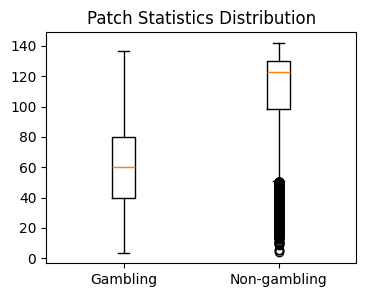

In [10]:
print('\n=== [EDA 1] Local Patch Statistics ===')
patch_vals = X_samp[:, groups['patch'][0]:groups['patch'][1]]
p_g, p_ng = patch_vals[gambling_mask].mean(), patch_vals[nongambling_mask].mean()
for label, mask in [('Gambling', gambling_mask), ('Non-gambling', nongambling_mask)]:
    print(f'  {label}: mean={patch_vals[mask].mean():.3f} ± {patch_vals[mask].std():.3f}')
print_ratio_insight(p_g, p_ng, 'tinggi nilai statistik patch lokalnya')

plt.figure(figsize=(4, 3))
plt.boxplot([patch_vals[gambling_mask].mean(axis=1), patch_vals[nongambling_mask].mean(axis=1)], labels=['Gambling', 'Non-gambling'])
plt.title('Patch Statistics Distribution')
plt.show()

### EDA RGB Histogram


=== [EDA 2] RGB Histogram Distribution ===
  Gambling: mean=0.031 ± 0.075
  Non-gambling: mean=0.031 ± 0.106
INSIGHT: Gambling 1.0× lebih dominan penggunaan warna dasar RGB-nya dibanding Non-gambling


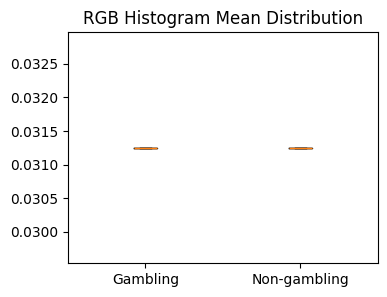

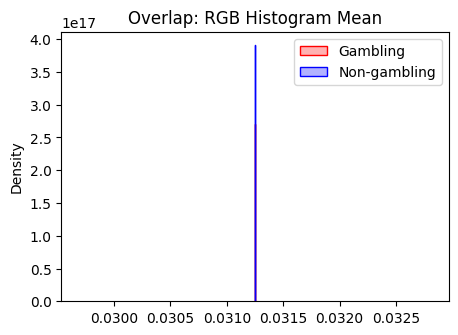

In [28]:
print('\n=== [EDA 2] RGB Histogram Distribution ===')
rgb_vals = X_samp[:, groups['rgb_hist'][0]:groups['rgb_hist'][1]]
rgb_g, rgb_ng = rgb_vals[gambling_mask].mean(), rgb_vals[nongambling_mask].mean()
for label, mask in [('Gambling', gambling_mask), ('Non-gambling', nongambling_mask)]:
    print(f'  {label}: mean={rgb_vals[mask].mean():.3f} ± {rgb_vals[mask].std():.3f}')
print_ratio_insight(rgb_g, rgb_ng, 'dominan penggunaan warna dasar RGB-nya')

plt.figure(figsize=(4, 3))
plt.boxplot([rgb_vals[gambling_mask].mean(axis=1), rgb_vals[nongambling_mask].mean(axis=1)], labels=['Gambling', 'Non-gambling'])
plt.title('RGB Histogram Mean Distribution')
plt.show()

plt.figure(figsize=(5, 3.5))
sns.kdeplot(rgb_vals[gambling_mask].mean(axis=1), label='Gambling', fill=True, color='red', alpha=0.3)
sns.kdeplot(rgb_vals[nongambling_mask].mean(axis=1), label='Non-gambling', fill=True, color='blue', alpha=0.3)
plt.title('Overlap: RGB Histogram Mean')
plt.legend()
plt.show()

### EDA HSV Histogram


=== [EDA 3] HSV Histogram (Color Saturation/Hue) ===
  Gambling: mean=0.501 ± 1.666
  Non-gambling: mean=0.501 ± 2.650
INSIGHT: Non-gambling 1.0× lebih vivid/jenuh tingkat warnanya (Saturation/Hue) dibanding Gambling


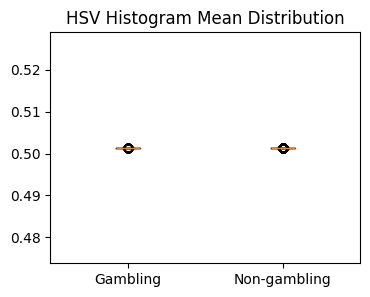

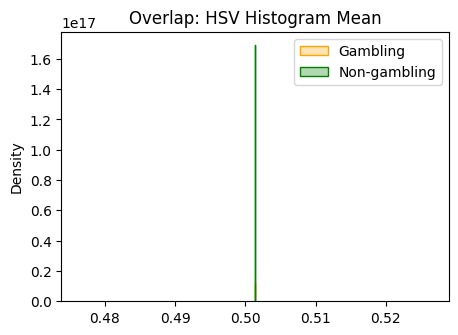

In [29]:
print('\n=== [EDA 3] HSV Histogram (Color Saturation/Hue) ===')
hsv_vals = X_samp[:, groups['hsv_hist'][0]:groups['hsv_hist'][1]]
hsv_g, hsv_ng = hsv_vals[gambling_mask].mean(), hsv_vals[nongambling_mask].mean()
for label, mask in [('Gambling', gambling_mask), ('Non-gambling', nongambling_mask)]:
    print(f'  {label}: mean={hsv_vals[mask].mean():.3f} ± {hsv_vals[mask].std():.3f}')
print_ratio_insight(hsv_g, hsv_ng, 'vivid/jenuh tingkat warnanya (Saturation/Hue)')

plt.figure(figsize=(4, 3))
plt.boxplot([hsv_vals[gambling_mask].mean(axis=1), hsv_vals[nongambling_mask].mean(axis=1)], labels=['Gambling', 'Non-gambling'])
plt.title('HSV Histogram Mean Distribution')
plt.show()

plt.figure(figsize=(5, 3.5))
sns.kdeplot(hsv_vals[gambling_mask].mean(axis=1), label='Gambling', fill=True, color='orange', alpha=0.3)
sns.kdeplot(hsv_vals[nongambling_mask].mean(axis=1), label='Non-gambling', fill=True, color='green', alpha=0.3)
plt.title('Overlap: HSV Histogram Mean')
plt.legend()
plt.show()

### EDA Edge Density


=== [EDA 4] Edge Density (Mean Magnitude) ===
  Gambling: mean=0.168 ± 0.051
  Non-gambling: mean=0.130 ± 0.038
INSIGHT: Gambling 1.3× lebih padat garis tepinya (tekstur gambar lebih kompleks) dibanding Non-gambling


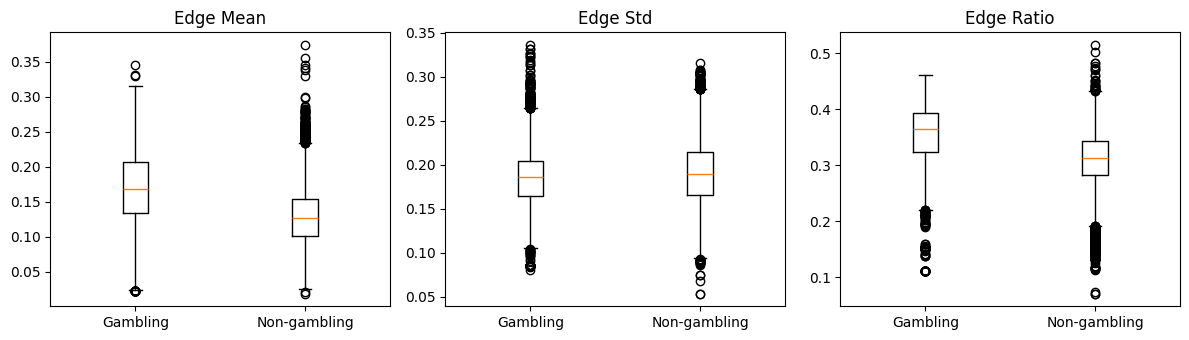

In [13]:
print('\n=== [EDA 4] Edge Density (Mean Magnitude) ===')
edge_vals = X_samp[:, groups['edge'][0]:groups['edge'][1]]
e_g, e_ng = edge_vals[gambling_mask, 0].mean(), edge_vals[nongambling_mask, 0].mean()
for label, mask in [('Gambling', gambling_mask), ('Non-gambling', nongambling_mask)]:
    print(f'  {label}: mean={edge_vals[mask, 0].mean():.3f} ± {edge_vals[mask, 0].std():.3f}')
print_ratio_insight(e_g, e_ng, 'padat garis tepinya (tekstur gambar lebih kompleks)')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for i, metric in enumerate(['Edge Mean', 'Edge Std', 'Edge Ratio']):
    axes[i].boxplot([edge_vals[gambling_mask, i], edge_vals[nongambling_mask, i]], labels=['Gambling', 'Non-gambling'])
    axes[i].set_title(metric)
plt.tight_layout()
plt.show()

### EDA Warm Color Ratio


=== [EDA 5] Warm Color Ratio ===
  Gambling: mean=0.588 ± 0.278
  Non-gambling: mean=0.614 ± 0.260
INSIGHT: Non-gambling 1.0× lebih banyak menggunakan spektrum warna hangat (merah/oranye/kuning) dibanding Gambling


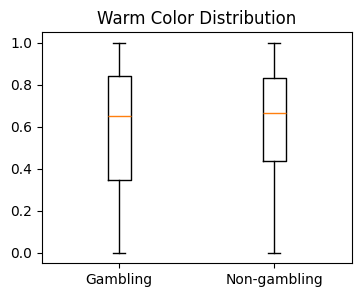

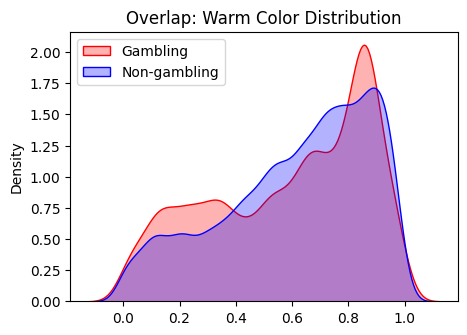

In [30]:
print('\n=== [EDA 5] Warm Color Ratio ===')
warm_vals = X_samp[:, groups['warm'][0]:groups['warm'][1]]
w_g, w_ng = warm_vals[gambling_mask, 0].mean(), warm_vals[nongambling_mask, 0].mean()

for label, mask in [('Gambling', gambling_mask), ('Non-gambling', nongambling_mask)]:
    print(f'  {label}: mean={warm_vals[mask, 0].mean():.3f} ± {warm_vals[mask, 0].std():.3f}')
    
print_ratio_insight(w_g, w_ng, 'banyak menggunakan spektrum warna hangat (merah/oranye/kuning)')

plt.figure(figsize=(4, 3))
plt.boxplot([warm_vals[gambling_mask, 0], warm_vals[nongambling_mask, 0]], labels=['Gambling', 'Non-gambling'])
plt.title('Warm Color Distribution')
plt.show()

plt.figure(figsize=(5, 3.5))
sns.kdeplot(warm_vals[gambling_mask, 0], label='Gambling', fill=True, color='red', alpha=0.3)
sns.kdeplot(warm_vals[nongambling_mask, 0], label='Non-gambling', fill=True, color='blue', alpha=0.3)
plt.title('Overlap: Warm Color Distribution')
plt.legend()
plt.show()

### EDA Color Variance 4x4 Grid


=== [EDA 6] Color Variance (Grid-based Color Changes) ===
  Gambling: mean=29.762 ± 16.085
  Non-gambling: mean=38.521 ± 20.970
INSIGHT: Non-gambling 1.3× lebih bervariasi perubahan kontras antar grid wilayahnya dibanding Gambling


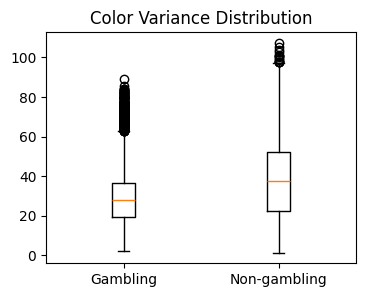

In [15]:
print('\n=== [EDA 6] Color Variance (Grid-based Color Changes) ===')
var_vals = X_samp[:, groups['color_var'][0]:groups['color_var'][1]]
v_g, v_ng = var_vals[gambling_mask].mean(), var_vals[nongambling_mask].mean()
for label, mask in [('Gambling', gambling_mask), ('Non-gambling', nongambling_mask)]:
    print(f'  {label}: mean={var_vals[mask].mean():.3f} ± {var_vals[mask].std():.3f}')
print_ratio_insight(v_g, v_ng, 'bervariasi perubahan kontras antar grid wilayahnya')

plt.figure(figsize=(4, 3))
plt.boxplot([var_vals[gambling_mask].mean(axis=1), var_vals[nongambling_mask].mean(axis=1)], labels=['Gambling', 'Non-gambling'])
plt.title('Color Variance Distribution')
plt.show()

### EDA Colorfulness Index


=== [EDA 7] Colorfulness Metric ===
  Gambling: mean=62.578 ± 25.031
  Non-gambling: mean=40.270 ± 26.002
INSIGHT: Gambling 1.6× lebih colorful (kaya akan kombinasi ragam warna berbeda) dibanding Non-gambling


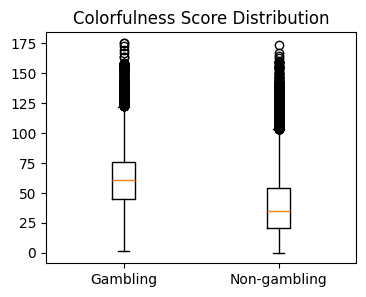

In [16]:
print('\n=== [EDA 7] Colorfulness Metric ===')
cf_vals = X_samp[:, groups['colorfulness'][0]:groups['colorfulness'][1]]
cf_g, cf_ng = cf_vals[gambling_mask, 0].mean(), cf_vals[nongambling_mask, 0].mean()
for label, mask in [('Gambling', gambling_mask), ('Non-gambling', nongambling_mask)]:
    print(f'  {label}: mean={cf_vals[mask, 0].mean():.3f} ± {cf_vals[mask, 0].std():.3f}')
print_ratio_insight(cf_g, cf_ng, 'colorful (kaya akan kombinasi ragam warna berbeda)')

plt.figure(figsize=(4, 3))
plt.boxplot([cf_vals[gambling_mask, 0], cf_vals[nongambling_mask, 0]], labels=['Gambling', 'Non-gambling'])
plt.title('Colorfulness Score Distribution')
plt.show()

### EDA Brightness Distribution


=== [EDA 8] Brightness (Gelap / Terang) ===
  Gambling: mean=0.423 ± 0.263
  Non-gambling: mean=0.097 ± 0.178
INSIGHT: Gambling 4.4× lebih terang tingkat pencahayaan gambarnya dibanding Non-gambling


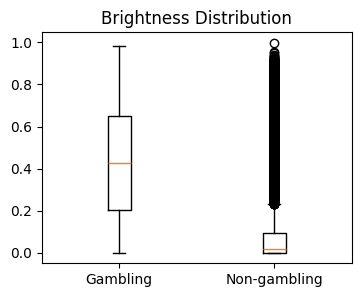

In [17]:
print('\n=== [EDA 8] Brightness (Gelap / Terang) ===')
bright_vals = X_samp[:, groups['brightness'][0]:groups['brightness'][1]]
b_g, b_ng = bright_vals[gambling_mask, 0].mean(), bright_vals[nongambling_mask, 0].mean()
for label, mask in [('Gambling', gambling_mask), ('Non-gambling', nongambling_mask)]:
    print(f'  {label}: mean={bright_vals[mask, 0].mean():.3f} ± {bright_vals[mask, 0].std():.3f}')
print_ratio_insight(b_g, b_ng, 'terang tingkat pencahayaan gambarnya')

plt.figure(figsize=(4, 3))
plt.boxplot([bright_vals[gambling_mask, 0], bright_vals[nongambling_mask, 0]], labels=['Gambling', 'Non-gambling'])
plt.title('Brightness Distribution')
plt.show()

* (`warm`, `hsv_hist`, `rgb_hist`): Berdasarkan grafik distribusi KDE, ketiga fitur ini menunjukkan visualisasi kurva yang tumpang tindih (overlap) di area tengah. Akibatnya, informasi warna global ini tidak memiliki daya pisah (*separability*) yang bersih dan berpotensi menjadi *noise* bagi model.

### EDA Feature


=== FINAL RESULT: Feature Importance by Group ===
  brightness      :  45.0%
  colorfulness    :  12.5%
  color_var       :  10.9%
  edge            :   9.2%
  rgb_hist        :   7.3%
  patch           :   6.9%
  hsv_hist        :   5.0%
  warm            :   3.1%


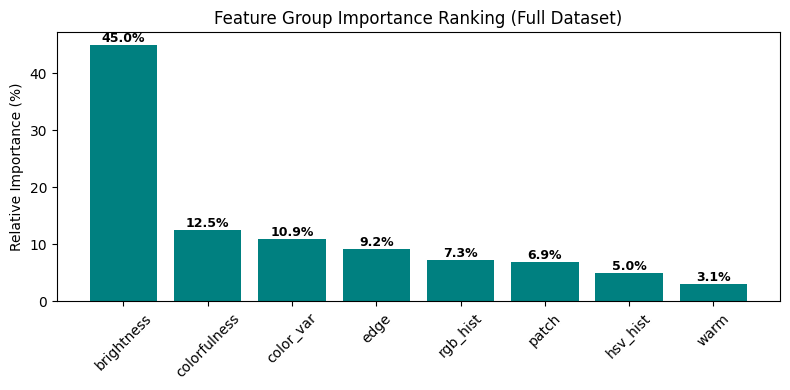

In [32]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
rf_model.fit(X_samp, y_samp)

group_imp = {}
for name, (start, end) in groups.items():
    group_imp[name] = rf_model.feature_importances_[start:end].mean()

sorted_imp = sorted(group_imp.items(), key=lambda x: x[1], reverse=True)
total_imp = sum(v for _, v in sorted_imp)

print('\n=== FINAL RESULT: Feature Importance by Group ===')
for name, imp in sorted_imp:
    print(f'  {name:15s} : {imp*100/total_imp:5.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
names, vals = zip(*sorted_imp)
rel_imp = np.array(vals) * 100 / total_imp

bars = ax.bar(names, rel_imp, color='teal')
ax.set_ylabel('Relative Importance (%)')
ax.set_title('Feature Group Importance Ranking (Full Dataset)')
ax.tick_params(axis='x', rotation=45)

for bar, v in zip(bars, rel_imp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

* `brightness` (45.0%): Fitur ini memegang kendali tertinggi. Hal ini membuktikan adanya pola *non-linear* yang kuat. Website judi cenderung memiliki desain pencahayaan ekstrem—entah sangat gelap (*dark mode/casino theme*) atau sangat terang dengan kontras tinggi.
* `colorfulness` (12.5%): Fitur kejenuhan warna ini berada di posisi kedua, menandakan intensitas "keramaian" warna pada website judi adalah sinyal penting yang diandalkan oleh model.

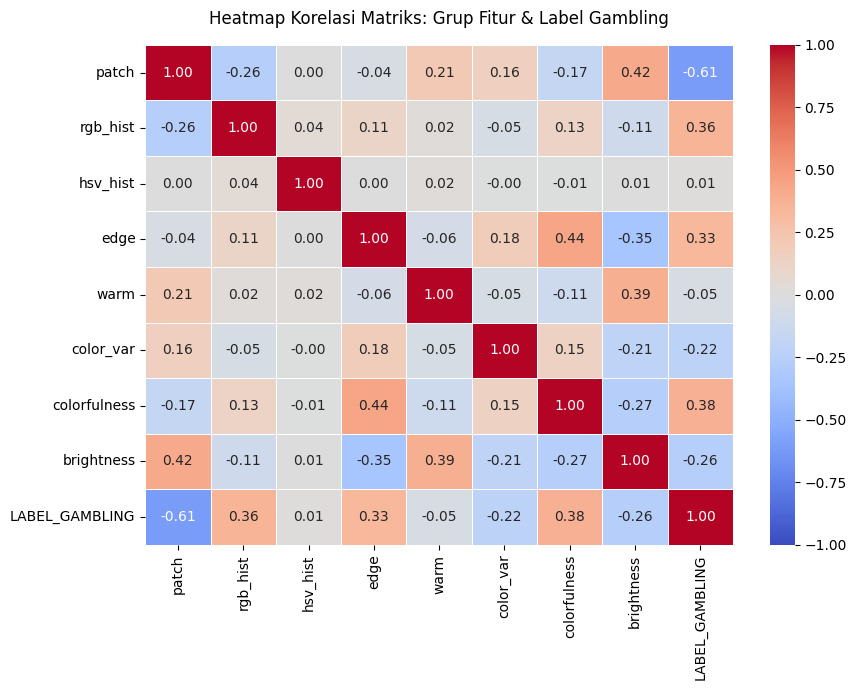

In [34]:
fitur_summary = {}
for nama_grup, (start, end) in groups.items():
    fitur_summary[nama_grup] = X_samp[:, start:end].mean(axis=1)

fitur_summary['LABEL_GAMBLING'] = y_samp

df_korelasi = pd.DataFrame(fitur_summary)
matriks_korelasi = df_korelasi.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    matriks_korelasi, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title('Heatmap Korelasi Matriks: Grup Fitur & Label Gambling', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

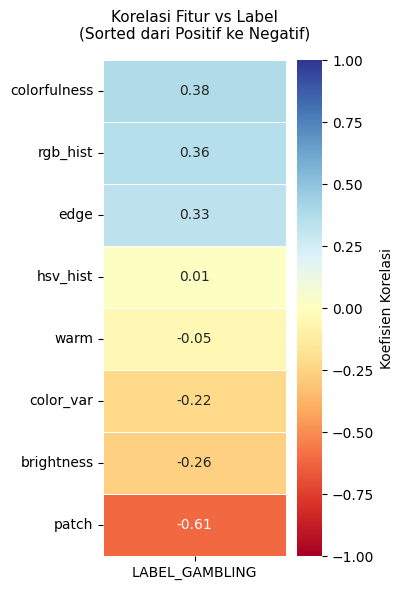

In [35]:
plt.figure(figsize=(4, 6))
korelasi_ke_label = matriks_korelasi[['LABEL_GAMBLING']].drop('LABEL_GAMBLING').sort_values(by='LABEL_GAMBLING', ascending=False)

sns.heatmap(
    korelasi_ke_label, 
    annot=True, 
    cmap='RdYlBu', 
    fmt='.2f', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={'label': 'Koefisien Korelasi'}
)
plt.title('Korelasi Fitur vs Label\n(Sorted dari Positif ke Negatif)', fontsize=11, pad=15)
plt.tight_layout()
plt.show()

* `patch` (-0.61): Meskipun fitur *patch* lokal mencatatkan *importance* yang relatif kecil di model (6.9%), ia merupakan pemenang utama di korelasi linear. Korelasi negatif kuat ini menandakan bahwa struktur tekstur lokal atau susunan komponen gambar tertentu pada layout website bekerja sebagai komponen pembatas (*linear constraint*) yang sangat konsisten untuk mengunci identitas kelas.
* Korelasi Pendukung: Fitur struktural lain seperti `edge` (+0.33) dan `color_var` (-0.22) menunjukkan korelasi yang sehat tanpa menunjukkan grafik distribusi yang *overlap*.

## Feature Selection


Berdasarkan sintesis ketiga analisis di atas, diambil keputusan strategis untuk **membuang fitur yang memicu noise/overlap** dan hanya mempertahankan fitur yang memiliki *signal* kontribusi nyata (baik lewat jalur Importance maupun Korelasi Linear).

### Tabel Keputusan Akhir Filtrasi Fitur

| Nama Fitur | Dimensi | Status | Justifikasi |
| :--- | :---: | :---: | :--- |
| **`brightness`** | 2 | **Simpan** | Juara 1 Feature Importance (45.0%). Menangkap pola pencahayaan global non-linear. |
| **`colorfulness`** | 1 | **Simpan** | Kontribusi stabil (12.5% Importance) dan memiliki tren korelasi linear positif (+0.38). |
| **`color_var`** | 3 | **Simpan** | Kontribusi penting ke-3 di model pohon (10.9%) untuk mengukur variasi kompleksitas warna. |
| **`edge`** | 3 | **Simpan** | Kontribusi 9.2% Importance dengan korelasi +0.33. Sangat baik dalam mendeteksi kepadatan teks/UI. |
| **`patch`** | 60 | **Simpan** | Juara 1 Korelasi Linear (-0.61). Pengunci pola struktur layout lokal yang sangat konsisten. |
| **`rgb_hist`** | - | *Buang* | Meskipun memiliki korelasi, kurva KDE overlap terlalu tebal. Redundan dengan `colorfulness`. |
| **`hsv_hist`** | - | *Buang* | Korelasi mendekati nol (+0.01) dan memiliki tingkat kepentingan rendah (5.0%). |
| **`warm`** | - | *Buang* | Pure Noise. Nilai kepentingan terendah (3.1%) dan kurva KDE terbukti tumpang tindih total. |

In [36]:
X_patch        = X_samp[:, groups['patch'][0]:groups['patch'][1]]
X_edge         = X_samp[:, groups['edge'][0]:groups['edge'][1]]
X_color_var    = X_samp[:, groups['color_var'][0]:groups['color_var'][1]]
X_colorfulness = X_samp[:, groups['colorfulness'][0]:groups['colorfulness'][1]]
X_brightness   = X_samp[:, groups['brightness'][0]:groups['brightness'][1]]

In [37]:
X_filtered_raw = np.hstack([
    X_patch, 
    X_edge, 
    X_color_var, 
    X_colorfulness, 
    X_brightness
])

In [38]:
scaler_filtered = StandardScaler()
X_filtered_scaled = scaler_filtered.fit_transform(X_filtered_raw)

In [39]:
ids_clean = df_cleaned['Webpage_id'].values

In [41]:
np.save(BIN_DIR / 'image_features.npy', X_filtered_scaled)
np.save(BIN_DIR / 'image_ids.npy', ids_clean)
joblib.dump(scaler_filtered, BIN_DIR / 'image_scaler.pkl')

['bin/image_scaler.pkl']

In [42]:
TOTAL_DIM_FILTERED = PATCH_DIM + EDGE_DIM + CVAR_DIM + CF_DIM + BR_DIM

assert X_filtered_scaled.shape[1] == TOTAL_DIM_FILTERED, f"Mismatch: {X_filtered_scaled.shape[1]} vs {TOTAL_DIM_FILTERED}"

print(f'Matriks Berhasil Disimpan! Shape: {X_filtered_scaled.shape}')
print(f'Total Dimensi Bersih Akhir      : {X_filtered_scaled.shape[1]} Dimensi')

Matriks Berhasil Disimpan! Shape: (37811, 69)
Total Dimensi Bersih Akhir      : 69 Dimensi


## Feature extraction untuk model.py

In [43]:
def extract_features_inference(img_path):
    """
    Ekstraksi Fitur Gambar Ringkas (69 Dimensi) untuk Tahap Inferensi.
    fitur terpilih: Patch, Edge, Color Var, Colorfulness, Brightness.
    """
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize(RESIZE, Image.LANCZOS)
    arr = np.array(img_resized, dtype=np.uint8)
    arr_float = arr / 255.0

    # 1. Patch features (10 patches x 3 channel x 2 stats = 60 dim)
    patches = extract_patches_2d(arr, patch_size=PATCH_SIZE, max_patches=MAX_PATCHES)
    patch_feat = []
    for p in patches:
        for c in range(3):
            patch_feat.append(p[:, :, c].mean())
            patch_feat.append(p[:, :, c].std())
    patch_feat = np.array(patch_feat)

    # 2. Edge density (3 dim)
    gray = np.array(img_resized.convert('L'), dtype=np.float64)
    edges_x = sobel(gray, axis=1)
    edges_y = sobel(gray, axis=0)
    edges_mag = np.hypot(edges_x, edges_y)
    max_mag = edges_mag.max()
    if max_mag > 0:
        edge_feat = np.array([
            edges_mag.mean() / max_mag, 
            edges_mag.std() / max_mag,
            (edges_mag > edges_mag.mean()).sum() / edges_mag.size
        ])
    else:
        edge_feat = np.zeros(3)

    # 3. Color variance 4x4 grid (3 dim)
    h_cells, w_cells = 4, 4
    cell_h, cell_w = arr.shape[0] // h_cells, arr.shape[1] // w_cells
    cell_means = np.zeros((h_cells * w_cells, 3))
    idx = 0
    for i in range(h_cells):
        for j in range(w_cells):
            cell = arr[i * cell_h : (i + 1) * cell_h, j * cell_w : (j + 1) * cell_w]
            cell_means[idx] = cell.mean(axis=(0, 1))
            idx += 1
    color_var = cell_means.std(axis=0)

    # 4. Colorfulness index Hasler & Susstrunk (1 dim)
    r, g, b = arr[:, :, 0].astype(float), arr[:, :, 1].astype(float), arr[:, :, 2].astype(float)
    rg = r - g
    yb = 0.5 * (r + g) - b
    colorfulness = np.array([
        np.sqrt(rg.std()**2 + yb.std()**2) + 0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2)
    ])

    # 5. Brightness distribution dark_ratio, bright_ratio (2 dim)
    hsv = rgb_to_hsv(arr_float)
    v_ch = hsv[:, :, 2]
    dark_ratio = (v_ch < 0.2).sum() / v_ch.size
    bright_ratio = (v_ch > 0.8).sum() / v_ch.size
    brightness_dist = np.array([dark_ratio, bright_ratio])

    features = np.concatenate([
        patch_feat,       # 60 Dim
        edge_feat,        # 3 Dim
        color_var,        # 3 Dim
        colorfulness,     # 1 Dim
        brightness_dist   # 2 Dim
    ])

    return features